# ES Futures Trend Trading Strategy
Backtest trend-following strategy on SPX using ES futures specifications

In [54]:
# Import required libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [55]:
# Fetch SPX 5-minute data
print("Fetching SPX data...")

# SPX ticker: ^GSPC or ^SPX
ticker = "^GSPC"

# Fetch maximum available 5-minute data (typically ~60 days)
data = yf.download(ticker, period="60d", interval="5m", progress=False)

# Flatten column index if MultiIndex (happens with yfinance)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in data.columns.values]
    # If columns have suffixes like 'Close_^GSPC', strip them
    data.columns = [col.split('_')[0] if '_' in col else col for col in data.columns]

# Clean data
data = data.dropna()

print(f"Data fetched: {len(data)} bars")
print(f"Date range: {data.index[0]} to {data.index[-1]}")
print(f"\nFirst few rows:")
print(data.head())
print(f"\nColumn names: {data.columns.tolist()}")

Fetching SPX data...
Data fetched: 4556 bars
Date range: 2025-12-26 14:30:00+00:00 to 2026-03-24 19:55:00+00:00

First few rows:
                                 Close         High          Low         Open  \
Datetime                                                                        
2025-12-26 14:30:00+00:00  6938.770020  6940.540039  6932.430176  6936.020020   
2025-12-26 14:35:00+00:00  6942.229980  6942.709961  6937.359863  6938.520020   
2025-12-26 14:40:00+00:00  6944.479980  6944.799805  6941.359863  6942.180176   
2025-12-26 14:45:00+00:00  6941.330078  6945.770020  6941.299805  6944.680176   
2025-12-26 14:50:00+00:00  6937.529785  6941.520020  6934.020020  6941.370117   

                             Volume  
Datetime                             
2025-12-26 14:30:00+00:00         0  
2025-12-26 14:35:00+00:00  25914450  
2025-12-26 14:40:00+00:00  22664063  
2025-12-26 14:45:00+00:00  22401865  
2025-12-26 14:50:00+00:00  21521448  

Column names: ['Close', 'High', 'Low

## Calculate Technical Indicators
Calculate 9 EMA, 15 EMA, 14-period RSI, and ATR

In [56]:
# Calculate indicators
df = data.copy()

# EMAs
df['EMA_9'] = df['Close'].ewm(span=9, adjust=False).mean()
df['EMA_15'] = df['Close'].ewm(span=15, adjust=False).mean()

# RSI (14-period)
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI'] = calculate_rsi(df['Close'], 14)

# ATR (14-period)
df['H-L'] = df['High'] - df['Low']
df['H-PC'] = abs(df['High'] - df['Close'].shift(1))
df['L-PC'] = abs(df['Low'] - df['Close'].shift(1))
df['TR'] = df[['H-L', 'H-PC', 'L-PC']].max(axis=1)
df['ATR'] = df['TR'].rolling(window=14).mean()

# EMA Gap
df['EMA_Gap'] = abs(df['EMA_9'] - df['EMA_15'])

# Drop temporary columns
df = df.drop(['H-L', 'H-PC', 'L-PC', 'TR'], axis=1)

# Drop NaN rows (from indicator calculations)
df = df.dropna()

print(f"Indicators calculated. Data shape: {df.shape}")
print(f"\nSample data:")
print(df[['Close', 'EMA_9', 'EMA_15', 'RSI', 'ATR', 'EMA_Gap']].tail())

Indicators calculated. Data shape: (4543, 10)

Sample data:
                                 Close        EMA_9       EMA_15        RSI  \
Datetime                                                                      
2026-03-24 19:35:00+00:00  6565.270020  6572.238155  6572.632878  45.671500   
2026-03-24 19:40:00+00:00  6563.759766  6570.542478  6571.523739  40.417959   
2026-03-24 19:45:00+00:00  6560.979980  6568.629978  6570.205769  19.967797   
2026-03-24 19:50:00+00:00  6554.640137  6565.832010  6568.260065  22.300182   
2026-03-24 19:55:00+00:00  6557.379883  6564.141584  6566.900043  29.021745   

                                ATR   EMA_Gap  
Datetime                                       
2026-03-24 19:35:00+00:00  7.757882  0.394723  
2026-03-24 19:40:00+00:00  7.282192  0.981262  
2026-03-24 19:45:00+00:00  6.649309  1.575791  
2026-03-24 19:50:00+00:00  6.017892  2.428056  
2026-03-24 19:55:00+00:00  6.054304  2.758458  


## Position Tracking Class
Track open positions with trailing stop management

In [57]:
class Position:
    """Track a single ES futures contract position with trailing stop"""
    def __init__(self, entry_price, stop_loss, take_profit, contract_num, direction):
        self.entry_price = entry_price
        self.stop_loss = stop_loss
        self.take_profit = take_profit
        self.contract_num = contract_num  # 1 or 2
        self.direction = direction  # 'LONG' or 'SHORT'
        self.status = 'OPEN'
        self.exit_price = None
        self.exit_reason = None
        self.breakeven_activated = False
        self.trailing_activated = False
        self.highest_profit = 0  # For longs
        self.lowest_profit = 0  # For shorts
        
    def update_trailing_stop(self, current_price):
        """Update trailing stop based on profit level
        
        Trailing stop = 2 ticks (0.5 points = $25 for ES)
        """
        if self.direction == 'LONG':
            current_profit = current_price - self.entry_price
            
            # Track highest profit
            if current_profit > self.highest_profit:
                self.highest_profit = current_profit
            
            # Move to breakeven at +2 points profit (for contract 2 only)
            if self.contract_num == 2 and current_profit >= 2.0 and not self.breakeven_activated:
                self.stop_loss = self.entry_price
                self.breakeven_activated = True
                self.trailing_activated = True
            
            # Activate trailing stop after breakeven (trail by 2 ticks = 0.5 points = $25)
            if self.trailing_activated and current_profit > 2.0:
                new_stop = current_price - 0.5  # Trail by 2 ticks (0.5 points)
                if new_stop > self.stop_loss:
                    self.stop_loss = new_stop
                    
        elif self.direction == 'SHORT':
            current_profit = self.entry_price - current_price
            
            # Track lowest profit (most negative)
            if current_profit > self.lowest_profit:
                self.lowest_profit = current_profit
            
            # Move to breakeven at +2 points profit (for contract 2 only)
            if self.contract_num == 2 and current_profit >= 2.0 and not self.breakeven_activated:
                self.stop_loss = self.entry_price
                self.breakeven_activated = True
                self.trailing_activated = True
            
            # Activate trailing stop after breakeven (trail by 2 ticks = 0.5 points = $25)
            if self.trailing_activated and current_profit > 2.0:
                new_stop = current_price + 0.5  # Trail by 2 ticks (0.5 points)
                if new_stop < self.stop_loss:
                    self.stop_loss = new_stop
                    
    def check_exit(self, current_high, current_low):
        """Check if position should exit"""
        if self.status == 'CLOSED':
            return False
            
        if self.direction == 'LONG':
            # Check stop loss
            if current_low <= self.stop_loss:
                self.exit_price = self.stop_loss
                self.exit_reason = 'STOP_LOSS'
                self.status = 'CLOSED'
                return True
            # Check take profit
            if current_high >= self.take_profit:
                self.exit_price = self.take_profit
                self.exit_reason = 'TAKE_PROFIT'
                self.status = 'CLOSED'
                return True
                
        elif self.direction == 'SHORT':
            # Check stop loss
            if current_high >= self.stop_loss:
                self.exit_price = self.stop_loss
                self.exit_reason = 'STOP_LOSS'
                self.status = 'CLOSED'
                return True
            # Check take profit
            if current_low <= self.take_profit:
                self.exit_price = self.take_profit
                self.exit_reason = 'TAKE_PROFIT'
                self.status = 'CLOSED'
                return True
                
        return False
    
    def get_pnl(self):
        """Calculate P&L in dollars ($50 per point for ES)"""
        if self.exit_price is None:
            return 0
        
        if self.direction == 'LONG':
            points = self.exit_price - self.entry_price
        else:
            points = self.entry_price - self.exit_price
            
        return points * 50  # $50 per point for ES

print("Position class defined successfully!")

Position class defined successfully!


## Backtest Engine - ES Futures
Run the strategy with signal generation and position management

**ES Futures Specifications:**
- **Point Value**: $50 per point
- **Tick Size**: 0.25 points (1 tick)
- **Tick Value**: $12.50 per tick
- **Initial Margin**: ~$14,000 per contract
- **Trailing Stop**: 2 ticks (0.5 points = $25 per contract)

In [58]:
# Backtest parameters - ES Futures
STARTING_CAPITAL = 50000
MAX_RISK_PCT = 0.01  # 1% risk per trade (still used for stop distance validation)
POINT_VALUE = 50  # $50 per point for ES
TICK_SIZE = 0.25  # 1 tick = 0.25 points
TICK_VALUE = 12.50  # 1 tick = $12.50
ES_MARGIN = 14000  # Initial margin per ES contract (~$14,000)
MIN_ACCOUNT_BUFFER = 0.20  # Keep 20% of account as buffer (don't use all margin)

# Calculate max contracts based on margin
MAX_CONTRACTS = int((STARTING_CAPITAL * (1 - MIN_ACCOUNT_BUFFER)) / ES_MARGIN)

# Track state
account_balance = STARTING_CAPITAL
open_positions = []
trade_log = []
equity_curve = []
previous_ema_position = None  # Track previous EMA relationship
crossover_occurred = False
crossover_direction = None
crossover_bar = None

print(f"Starting backtest - ES Futures Trading...")
print(f"Initial capital: ${STARTING_CAPITAL:,.2f}")
print(f"ES Margin per contract: ${ES_MARGIN:,.2f}")
print(f"Max contracts (with {MIN_ACCOUNT_BUFFER*100:.0f}% buffer): {MAX_CONTRACTS}")
print(f"Point value: ${POINT_VALUE}/point, Tick value: ${TICK_VALUE}/tick")
print(f"\nProcessing {len(df)} bars...")

# Run backtest
for i in range(len(df)):
    current_time = df.index[i]
    # Access DataFrame directly and convert to Python scalars
    current_close = float(df['Close'].values[i])
    current_high = float(df['High'].values[i])
    current_low = float(df['Low'].values[i])
    ema_9 = float(df['EMA_9'].values[i])
    ema_15 = float(df['EMA_15'].values[i])
    rsi = float(df['RSI'].values[i])
    atr = float(df['ATR'].values[i])
    ema_gap = float(df['EMA_Gap'].values[i])
    
    # Update open positions - check for exits and update trailing stops
    for pos in open_positions[:]:  # Use slice to avoid modification during iteration
        # Update trailing stop
        pos.update_trailing_stop(current_close)
        
        # Check for exit
        if pos.check_exit(current_high, current_low):
            pnl = pos.get_pnl()
            account_balance += pnl
            
            trade_log.append({
                'entry_time': pos.entry_time,
                'exit_time': current_time,
                'direction': pos.direction,
                'contract': pos.contract_num,
                'entry_price': pos.entry_price,
                'exit_price': pos.exit_price,
                'exit_reason': pos.exit_reason,
                'pnl': pnl
            })
            
            open_positions.remove(pos)
    
    # Calculate available margin
    margin_used = len(open_positions) * ES_MARGIN
    margin_available = (account_balance * (1 - MIN_ACCOUNT_BUFFER)) - margin_used
    available_contracts = int(margin_available / ES_MARGIN)
    
    # Record equity
    unrealized_pnl = 0
    for pos in open_positions:
        if pos.direction == 'LONG':
            unrealized_pnl += (current_close - pos.entry_price) * POINT_VALUE
        else:
            unrealized_pnl += (pos.entry_price - current_close) * POINT_VALUE
    
    equity_curve.append({
        'time': current_time,
        'equity': account_balance + unrealized_pnl,
        'margin_used': margin_used
    })
    
    # Skip entry signals if we already have open positions
    if len(open_positions) > 0:
        continue
    
    # Detect EMA crossover
    current_ema_position = 'above' if ema_9 > ema_15 else 'below'
    
    if previous_ema_position is not None and current_ema_position != previous_ema_position:
        crossover_occurred = True
        crossover_direction = 'bullish' if current_ema_position == 'above' else 'bearish'
        crossover_bar = i
    
    previous_ema_position = current_ema_position
    
    # Check entry conditions AFTER crossover when gap reaches 2-4 points
    if crossover_occurred and (i - crossover_bar) <= 20:  # Check within 20 bars after crossover
        
        # Bullish entry: 9 EMA crossed above 15 EMA, RSI > 30, gap 2-4 points
        if crossover_direction == 'bullish' and rsi > 30 and 2.0 <= ema_gap <= 4.0:
            # Check if we have enough margin for 2 contracts
            if available_contracts >= 2:
                entry_price = current_close
                stop_loss = entry_price - atr
                
                # Validate stop distance (should risk ~1% of account)
                risk_per_contract = atr * POINT_VALUE
                total_risk = risk_per_contract * 2
                
                # Only enter if total risk is reasonable
                if total_risk <= (account_balance * MAX_RISK_PCT * 2):
                    # Create 2 contracts with different targets
                    # Contract 1: 1:1 R:R
                    pos1 = Position(entry_price, stop_loss, entry_price + atr, 1, 'LONG')
                    pos1.entry_time = current_time
                    
                    # Contract 2: 2:1 R:R with trailing stop
                    pos2 = Position(entry_price, stop_loss, entry_price + (2 * atr), 2, 'LONG')
                    pos2.entry_time = current_time
                    
                    open_positions.extend([pos1, pos2])
                    crossover_occurred = False
                    crossover_direction = None
        
        # Bearish entry: 9 EMA crossed below 15 EMA, RSI < 50, gap 2-4 points
        elif crossover_direction == 'bearish' and rsi < 50 and 2.0 <= ema_gap <= 4.0:
            # Check if we have enough margin for 2 contracts
            if available_contracts >= 2:
                entry_price = current_close
                stop_loss = entry_price + atr
                
                # Validate stop distance (should risk ~1% of account)
                risk_per_contract = atr * POINT_VALUE
                total_risk = risk_per_contract * 2
                
                # Only enter if total risk is reasonable
                if total_risk <= (account_balance * MAX_RISK_PCT * 2):
                    # Create 2 contracts with different targets
                    # Contract 1: 1:1 R:R
                    pos1 = Position(entry_price, stop_loss, entry_price - atr, 1, 'SHORT')
                    pos1.entry_time = current_time
                    
                    # Contract 2: 2:1 R:R with trailing stop
                    pos2 = Position(entry_price, stop_loss, entry_price - (2 * atr), 2, 'SHORT')
                    pos2.entry_time = current_time
                    
                    open_positions.extend([pos1, pos2])
                    crossover_occurred = False
                    crossover_direction = None

# Close any remaining open positions at market
for pos in open_positions:
    pos.exit_price = float(df['Close'].values[-1])
    pos.exit_reason = 'END_OF_DATA'
    pos.status = 'CLOSED'
    pnl = pos.get_pnl()
    account_balance += pnl
    
    trade_log.append({
        'entry_time': pos.entry_time,
        'exit_time': df.index[-1],
        'direction': pos.direction,
        'contract': pos.contract_num,
        'entry_price': pos.entry_price,
        'exit_price': pos.exit_price,
        'exit_reason': pos.exit_reason,
        'pnl': pnl
    })

print(f"\nBacktest complete!")
print(f"Total trades: {len(trade_log)}")
print(f"Final account balance: ${account_balance:,.2f}")
print(f"Total return: ${account_balance - STARTING_CAPITAL:,.2f} ({((account_balance - STARTING_CAPITAL) / STARTING_CAPITAL * 100):.2f}%)")

Starting backtest - ES Futures Trading...
Initial capital: $50,000.00
ES Margin per contract: $14,000.00
Max contracts (with 20% buffer): 2
Point value: $50/point, Tick value: $12.5/tick

Processing 4543 bars...

Backtest complete!
Total trades: 216
Final account balance: $57,230.84
Total return: $7,230.84 (14.46%)


## Performance Metrics
Calculate and display strategy performance

In [59]:
# Convert trade log to DataFrame
trades_df = pd.DataFrame(trade_log)

if len(trades_df) > 0:
    # Calculate metrics
    total_trades = len(trades_df)
    winning_trades = len(trades_df[trades_df['pnl'] > 0])
    losing_trades = len(trades_df[trades_df['pnl'] < 0])
    win_rate = (winning_trades / total_trades * 100) if total_trades > 0 else 0
    
    total_pnl = trades_df['pnl'].sum()
    avg_win = trades_df[trades_df['pnl'] > 0]['pnl'].mean() if winning_trades > 0 else 0
    avg_loss = trades_df[trades_df['pnl'] < 0]['pnl'].mean() if losing_trades > 0 else 0
    profit_factor = abs(trades_df[trades_df['pnl'] > 0]['pnl'].sum() / trades_df[trades_df['pnl'] < 0]['pnl'].sum()) if losing_trades > 0 else float('inf')
    
    # Calculate max drawdown
    equity_df = pd.DataFrame(equity_curve)
    equity_df['peak'] = equity_df['equity'].cummax()
    equity_df['drawdown'] = equity_df['equity'] - equity_df['peak']
    equity_df['drawdown_pct'] = (equity_df['drawdown'] / equity_df['peak']) * 100
    max_drawdown = equity_df['drawdown'].min()
    max_drawdown_pct = equity_df['drawdown_pct'].min()
    
    # Calculate return
    total_return = account_balance - STARTING_CAPITAL
    total_return_pct = (total_return / STARTING_CAPITAL) * 100
    
    # Separate by contract
    contract_1_trades = trades_df[trades_df['contract'] == 1]
    contract_2_trades = trades_df[trades_df['contract'] == 2]
    
    # Print summary
    print("=" * 60)
    print("BACKTEST PERFORMANCE SUMMARY")
    print("=" * 60)
    print(f"\n💰 ACCOUNT PERFORMANCE")
    print(f"  Starting Capital:    ${STARTING_CAPITAL:,.2f}")
    print(f"  Ending Balance:      ${account_balance:,.2f}")
    print(f"  Total Return:        ${total_return:,.2f} ({total_return_pct:.2f}%)")
    print(f"  Max Drawdown:        ${max_drawdown:,.2f} ({max_drawdown_pct:.2f}%)")
    
    print(f"\n📊 TRADE STATISTICS")
    print(f"  Total Trades:        {total_trades}")
    print(f"  Winning Trades:      {winning_trades}")
    print(f"  Losing Trades:       {losing_trades}")
    print(f"  Win Rate:            {win_rate:.2f}%")
    print(f"  Profit Factor:       {profit_factor:.2f}")
    
    print(f"\n💵 TRADE P&L")
    print(f"  Total P&L:           ${total_pnl:,.2f}")
    print(f"  Average Win:         ${avg_win:,.2f}")
    print(f"  Average Loss:        ${avg_loss:,.2f}")
    print(f"  Avg Win/Loss Ratio:  {abs(avg_win/avg_loss):.2f}" if avg_loss != 0 else "  Avg Win/Loss Ratio:  N/A")
    
    print(f"\n📈 BY CONTRACT")
    print(f"  Contract 1 (1:1 R:R):")
    print(f"    Trades: {len(contract_1_trades)}")
    print(f"    Total P&L: ${contract_1_trades['pnl'].sum():,.2f}")
    print(f"    Avg P&L: ${contract_1_trades['pnl'].mean():,.2f}")
    print(f"  Contract 2 (2:1 R:R with trailing):")
    print(f"    Trades: {len(contract_2_trades)}")
    print(f"    Total P&L: ${contract_2_trades['pnl'].sum():,.2f}")
    print(f"    Avg P&L: ${contract_2_trades['pnl'].mean():,.2f}")
    
    print(f"\n🎯 EXIT REASONS")
    exit_counts = trades_df['exit_reason'].value_counts()
    for reason, count in exit_counts.items():
        print(f"  {reason}: {count} ({count/total_trades*100:.1f}%)")
    
    print("=" * 60)
else:
    print("No trades were executed!")

BACKTEST PERFORMANCE SUMMARY

💰 ACCOUNT PERFORMANCE
  Starting Capital:    $50,000.00
  Ending Balance:      $57,230.84
  Total Return:        $7,230.84 (14.46%)
  Max Drawdown:        $-4,415.01 (-7.21%)

📊 TRADE STATISTICS
  Total Trades:        216
  Winning Trades:      121
  Losing Trades:       95
  Win Rate:            56.02%
  Profit Factor:       1.22

💵 TRADE P&L
  Total P&L:           $7,230.84
  Average Win:         $334.36
  Average Loss:        $-349.76
  Avg Win/Loss Ratio:  0.96

📈 BY CONTRACT
  Contract 1 (1:1 R:R):
    Trades: 108
    Total P&L: $2,050.69
    Avg P&L: $18.99
  Contract 2 (2:1 R:R with trailing):
    Trades: 108
    Total P&L: $5,180.15
    Avg P&L: $47.96

🎯 EXIT REASONS
  STOP_LOSS: 159 (73.6%)
  TAKE_PROFIT: 55 (25.5%)
  END_OF_DATA: 2 (0.9%)


## Trade Log
View detailed trade history

In [60]:
# Display trade log
if len(trades_df) > 0:
    # Format for better display
    display_df = trades_df.copy()
    display_df['pnl'] = display_df['pnl'].apply(lambda x: f"${x:,.2f}")
    display_df['entry_price'] = display_df['entry_price'].apply(lambda x: f"{x:.2f}")
    display_df['exit_price'] = display_df['exit_price'].apply(lambda x: f"{x:.2f}")
    
    print("DETAILED TRADE LOG:")
    print(display_df.to_string(index=False))
else:
    print("No trades to display")

DETAILED TRADE LOG:
               entry_time                 exit_time direction  contract entry_price exit_price exit_reason      pnl
2025-12-29 14:35:00+00:00 2025-12-29 14:40:00+00:00     SHORT         1     6916.24    6911.39 TAKE_PROFIT  $242.50
2025-12-29 14:35:00+00:00 2025-12-29 14:40:00+00:00     SHORT         2     6916.24    6912.85   STOP_LOSS  $169.51
2025-12-29 20:10:00+00:00 2025-12-29 20:25:00+00:00      LONG         1     6912.50    6910.28   STOP_LOSS $-111.03
2025-12-29 20:10:00+00:00 2025-12-29 20:25:00+00:00      LONG         2     6912.50    6910.28   STOP_LOSS $-111.03
2025-12-31 14:35:00+00:00 2025-12-31 14:40:00+00:00     SHORT         2     6887.70    6886.19   STOP_LOSS   $75.51
2025-12-31 14:35:00+00:00 2025-12-31 14:45:00+00:00     SHORT         1     6887.70    6884.09 TAKE_PROFIT  $180.36
2025-12-31 19:50:00+00:00 2025-12-31 20:00:00+00:00     SHORT         1     6868.34    6864.71 TAKE_PROFIT  $181.28
2025-12-31 19:50:00+00:00 2025-12-31 20:00:00+00:00 

## Visualizations
Plot equity curve and price chart with buy/sell signals

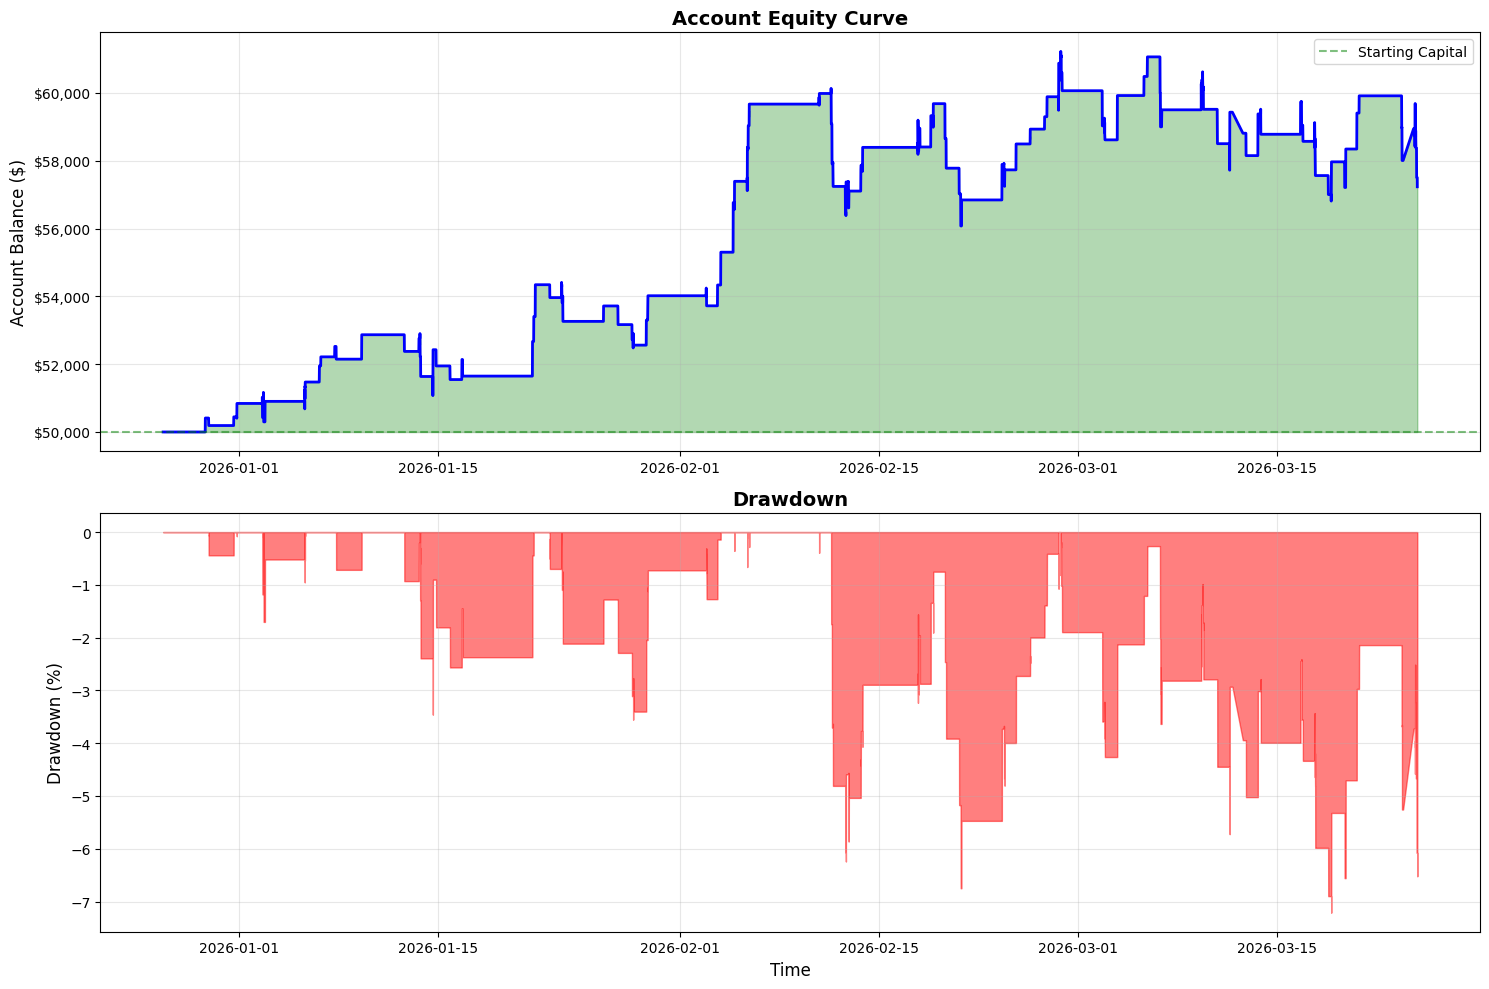

In [61]:
# Plot 1: Equity Curve
if len(equity_curve) > 0:
    equity_df = pd.DataFrame(equity_curve)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
    
    # Equity curve
    ax1.plot(equity_df['time'], equity_df['equity'], linewidth=2, color='blue')
    ax1.axhline(y=STARTING_CAPITAL, color='green', linestyle='--', alpha=0.5, label='Starting Capital')
    ax1.fill_between(equity_df['time'], STARTING_CAPITAL, equity_df['equity'], 
                     where=equity_df['equity'] >= STARTING_CAPITAL, alpha=0.3, color='green')
    ax1.fill_between(equity_df['time'], STARTING_CAPITAL, equity_df['equity'], 
                     where=equity_df['equity'] < STARTING_CAPITAL, alpha=0.3, color='red')
    ax1.set_title('Account Equity Curve', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Account Balance ($)', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    
    # Drawdown
    equity_df['peak'] = equity_df['equity'].cummax()
    equity_df['drawdown_pct'] = ((equity_df['equity'] - equity_df['peak']) / equity_df['peak']) * 100
    
    ax2.fill_between(equity_df['time'], 0, equity_df['drawdown_pct'], alpha=0.5, color='red')
    ax2.set_title('Drawdown', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Time', fontsize=12)
    ax2.set_ylabel('Drawdown (%)', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No equity data to plot")

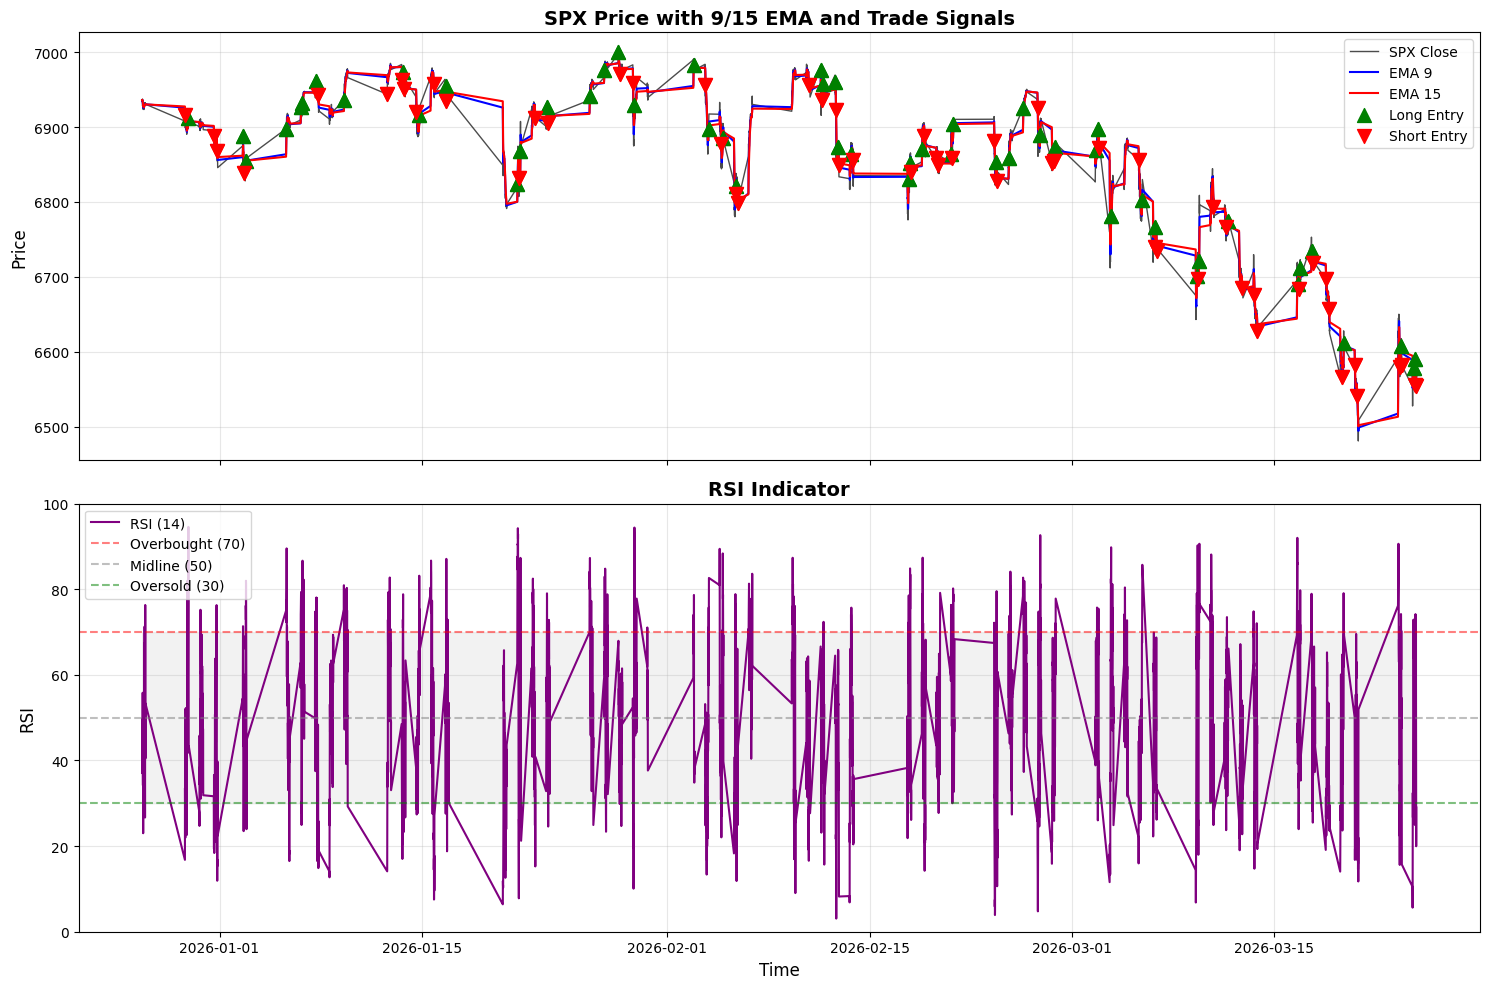

In [62]:
# Plot 2: Price chart with signals
if len(trades_df) > 0:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
    
    # Price and EMAs
    ax1.plot(df.index, df['Close'], label='SPX Close', linewidth=1, color='black', alpha=0.7)
    ax1.plot(df.index, df['EMA_9'], label='EMA 9', linewidth=1.5, color='blue')
    ax1.plot(df.index, df['EMA_15'], label='EMA 15', linewidth=1.5, color='red')
    
    # Mark entries and exits
    long_entries = trades_df[trades_df['direction'] == 'LONG']
    short_entries = trades_df[trades_df['direction'] == 'SHORT']
    
    if len(long_entries) > 0:
        ax1.scatter(long_entries['entry_time'], long_entries['entry_price'], 
                   color='green', marker='^', s=100, label='Long Entry', zorder=5)
    if len(short_entries) > 0:
        ax1.scatter(short_entries['entry_time'], short_entries['entry_price'],
                   color='red', marker='v', s=100, label='Short Entry', zorder=5)
    
    ax1.set_title('SPX Price with 9/15 EMA and Trade Signals', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Price', fontsize=12)
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    
    # RSI
    ax2.plot(df.index, df['RSI'], label='RSI (14)', linewidth=1.5, color='purple')
    ax2.axhline(y=70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
    ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Midline (50)')
    ax2.axhline(y=30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
    ax2.fill_between(df.index, 30, 70, alpha=0.1, color='gray')
    ax2.set_title('RSI Indicator', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Time', fontsize=12)
    ax2.set_ylabel('RSI', fontsize=12)
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 100)
    
    plt.tight_layout()
    plt.show()
else:
    print("No trades to plot")